In [1]:
!nvidia-smi

Thu Aug 20 18:49:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install tensorflow-gpu

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
!pip install -q kaggle

In [14]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [15]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [16]:
!ls -l ~/.kaggle/

total 4
-rw------- 1 root root 69 Aug 20 19:30 kaggle.json


In [17]:
!kaggle datasets download -d wenewone/cub2002011

Dataset URL: https://www.kaggle.com/datasets/wenewone/cub2002011
License(s): CC0-1.0
100% 1.49G/1.49G [00:18<00:00, 86.3MB/s]



In [18]:
!mkdir -p /content/CUB
!unzip -q /content/cub2002011.zip -d /content/CUB

In [20]:
import os

DATA_DIR = "/content/CUB/CUB_200_2011"

print("Dataset exists:", os.path.exists(DATA_DIR))
print("Images folder exists:", os.path.exists(os.path.join(DATA_DIR, "images")))

Dataset exists: True
Images folder exists: True


In [21]:
classes_file = os.path.join(DATA_DIR, "classes.txt")

class_names = []

with open(classes_file, "r") as f:
    for line in f:
        class_id, class_name = line.strip().split(" ", 1)
        class_names.append(class_name)

print("Number of classes:", len(class_names))
print(class_names[:10])

Number of classes: 200
['001.Black_footed_Albatross', '002.Laysan_Albatross', '003.Sooty_Albatross', '004.Groove_billed_Ani', '005.Crested_Auklet', '006.Least_Auklet', '007.Parakeet_Auklet', '008.Rhinoceros_Auklet', '009.Brewer_Blackbird', '010.Red_winged_Blackbird']


In [22]:
images_file = os.path.join(DATA_DIR, "images.txt")

image_data = []

with open(images_file, "r") as f:
    for line in f:
        image_id, image_path = line.strip().split(" ", 1)
        image_data.append((int(image_id), image_path))

print("Total images:", len(image_data))

Total images: 11788


In [23]:
labels_file = os.path.join(DATA_DIR, "image_class_labels.txt")

labels = {}

with open(labels_file, "r") as f:
    for line in f:
        image_id, class_id = line.strip().split()
        labels[int(image_id)] = int(class_id) - 1

In [24]:
split_file = os.path.join(DATA_DIR, "train_test_split.txt")

train_ids = []
test_ids = []

with open(split_file, "r") as f:
    for line in f:
        image_id, is_train = line.strip().split()

        image_id = int(image_id)
        is_train = int(is_train)

        if is_train == 1:
            train_ids.append(image_id)
        else:
            test_ids.append(image_id)

print("Training images:", len(train_ids))
print("Testing images:", len(test_ids))

Training images: 5994
Testing images: 5794


In [26]:
records = []

IMAGE_DIR = os.path.join(DATA_DIR, "images") # Define IMAGE_DIR here

for image_id, image_path in image_data:

    records.append({
        "image_id": image_id,
        "image_path": os.path.join(IMAGE_DIR, image_path),
        "label": labels[image_id]
    })

df = pd.DataFrame(records)

df.head()

,image_id,image_path,label
0,1,/content/CUB/CUB_200_2011/images/001.Black_foo...,0
1,2,/content/CUB/CUB_200_2011/images/001.Black_foo...,0
2,3,/content/CUB/CUB_200_2011/images/001.Black_foo...,0
3,4,/content/CUB/CUB_200_2011/images/001.Black_foo...,0
4,5,/content/CUB/CUB_200_2011/images/001.Black_foo...,0


In [27]:
train_id_set = set(train_ids)

df["split"] = df["image_id"].apply(
    lambda x: "train" if x in train_id_set else "test"
)

print(df["split"].value_counts())

split
train    5994
test     5794
Name: count, dtype: int64


In [29]:
from sklearn.model_selection import train_test_split

train_df = df[df["split"] == "train"].copy()
test_df = df[df["split"] == "test"].copy()

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 5094
Validation: 900
Test: 5794


In [52]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

In [31]:
def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32)

    return image, label

In [32]:
def make_dataset(dataframe, shuffle=False):

    paths = dataframe["image_path"].values
    labels_array = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels_array)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(1000)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [33]:
train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

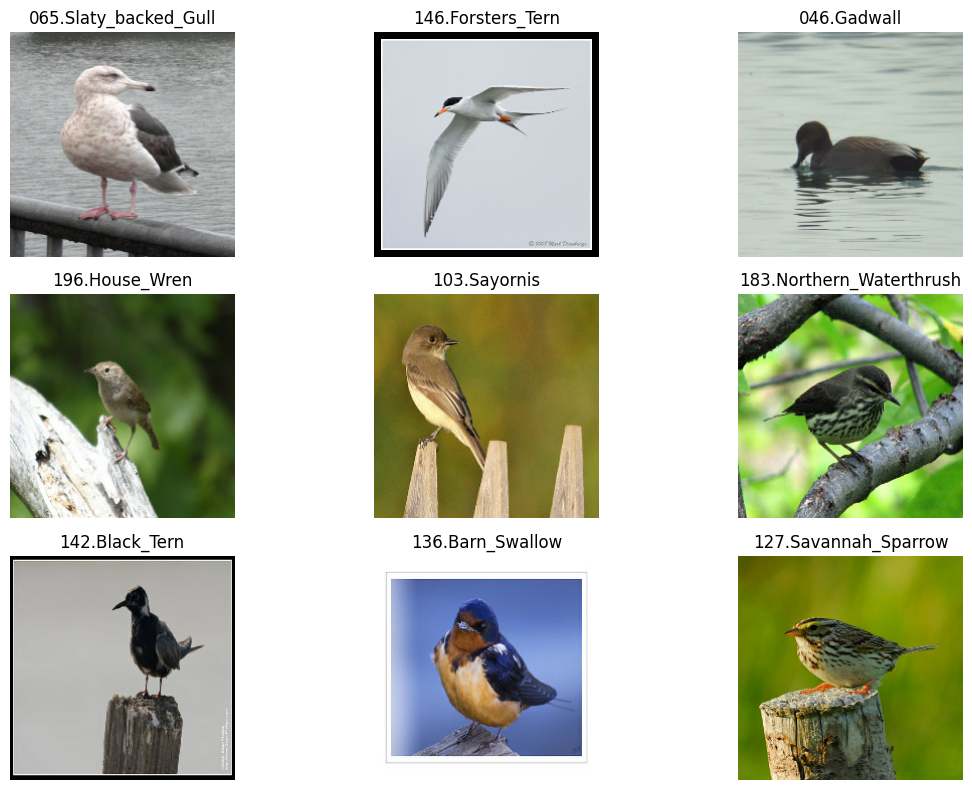

In [34]:
plt.figure(figsize=(12, 8))

for images, labels_batch in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels_batch[i].numpy()]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [94]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.08
    ),

    tf.keras.layers.RandomZoom(
        0.15
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
])

In [95]:
def augment(image, label):
    image = data_augmentation(image, training=True)
    return image, label

In [96]:
train_ds = train_ds.map(
    augment,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [53]:
def build_custom_cnn():

    model = keras.Sequential([
        layers.Input(shape=(256, 256, 3)),

        data_augmentation,

        layers.Rescaling(1./255),

        # Block 1
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Block 2
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Block 3
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Block 4
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.5),

        layers.Dense(512, activation="relu"),

        layers.Dropout(0.4),

        layers.Dense(200, activation="softmax")
    ])

    return model

In [37]:
custom_cnn = build_custom_cnn()

In [38]:
custom_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 507,528 (1.94 MB)

 Trainable params: 506,568 (1.93 MB)

 Non-trainable params: 960 (3.75 KB)

In [61]:
custom_cnn.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=3e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [59]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

In [62]:
import time
start_time = time.time()

history_cnn = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

cnn_training_time = time.time() - start_time

print(
    f"Training time: {cnn_training_time/60:.2f} minutes"
)

Epoch 1/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 36s 83ms/step - accuracy: 0.0730 - loss: 4.2954 - val_accuracy: 0.0622 - val_loss: 4.7245
Epoch 2/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - accuracy: 0.0807 - loss: 4.2250 - val_accuracy: 0.0567 - val_loss: 4.7306
Epoch 3/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.0823 - loss: 4.1932 - val_accuracy: 0.0633 - val_loss: 4.6125
Epoch 4/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - accuracy: 0.0876 - loss: 4.1341 - val_accuracy: 0.0767 - val_loss: 4.6280
Epoch 5/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.0909 - loss: 4.0918 - val_accuracy: 0.0678 - val_loss: 4.7007
Epoch 6/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 28s 83ms/step - accuracy: 0.0901 - loss: 4.0456 - val_accuracy: 0.0778 - val_loss: 4.5913
Epoch 7/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 32s 89ms/step - accuracy: 0.0976 - loss: 4.0355 - val_accuracy: 0.0767 - val_loss: 4.6485
Epoch 8/30
319/319 ━━━━━━━━━━━━━━━━━━━━ 36s 79ms/step - accuracy: 0.0946 - loss: 3.9966 - 

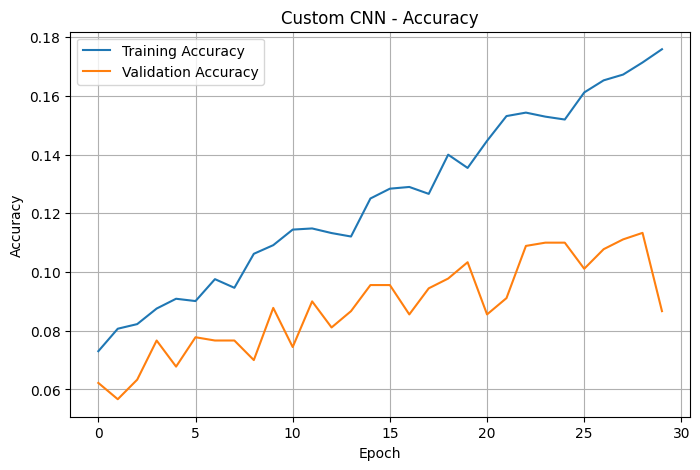

In [67]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Custom CNN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

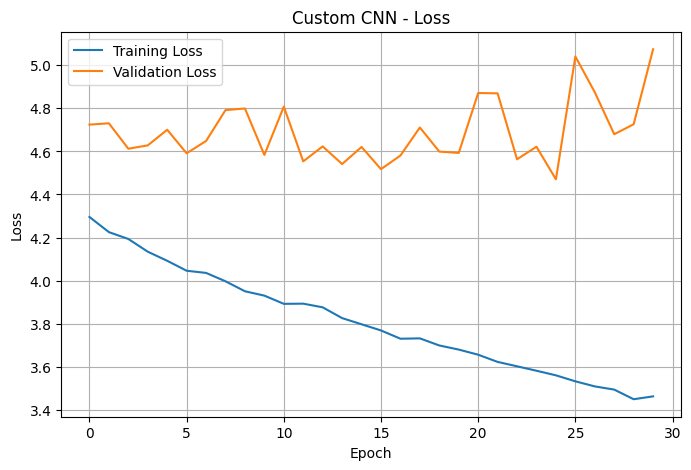

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_cnn.history["val_loss"],
    label="Validation Loss"
)

plt.title("Custom CNN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [47]:
test_loss, test_accuracy = custom_cnn.evaluate(
    test_ds,
    verbose=1
)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

363/363 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.0759 - loss: 4.4745
Test Accuracy: 7.59%


In [63]:
y_true = []
y_pred = []

for images, labels_batch in test_ds:

    predictions = custom_cnn.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels_batch.numpy()
    )

    y_pred.extend(
        predicted_classes
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [64]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

                                    precision    recall  f1-score   support

        001.Black_footed_Albatross       0.00      0.00      0.00        30
              002.Laysan_Albatross       0.02      0.03      0.03        30
               003.Sooty_Albatross       0.15      0.07      0.10        28
             004.Groove_billed_Ani       0.14      0.17      0.15        30
                005.Crested_Auklet       0.13      0.29      0.18        14
                  006.Least_Auklet       0.05      0.18      0.07        11
               007.Parakeet_Auklet       0.12      0.30      0.17        23
             008.Rhinoceros_Auklet       0.05      0.11      0.07        18
              009.Brewer_Blackbird       0.08      0.17      0.11        29
          010.Red_winged_Blackbird       0.40      0.53      0.46        30
               011.Rusty_Blackbird       0.00      0.00      0.00        30
       012.Yellow_headed_Blackbird       0.32      0.46      0.38        26
           

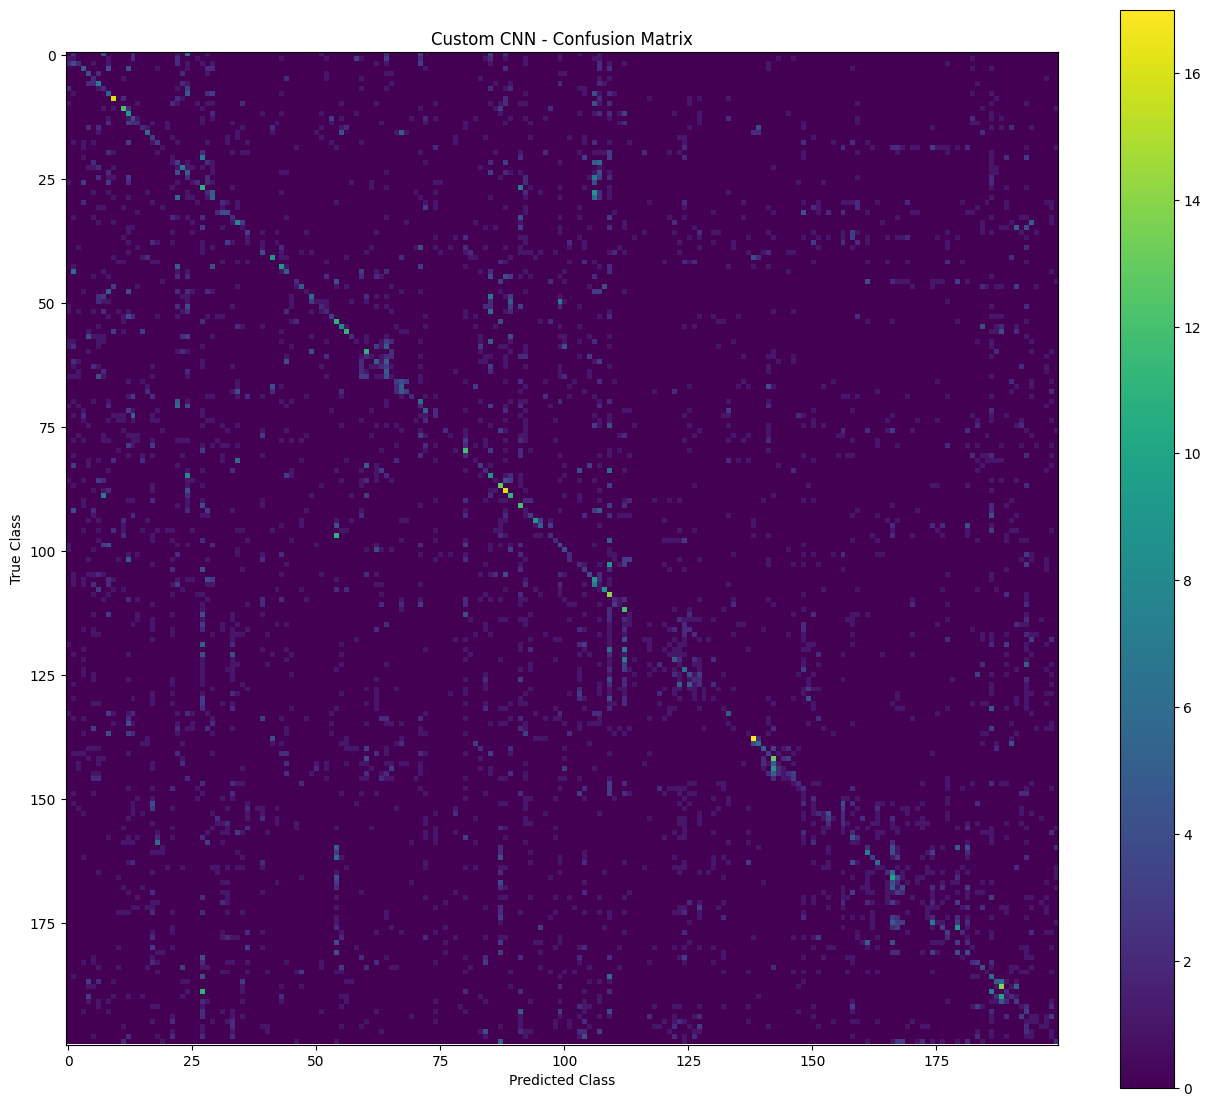

In [65]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(16, 14))

plt.imshow(cm)

plt.title("Custom CNN - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.colorbar()

plt.show()

In [66]:
custom_cnn.count_params()

507528

According to research paper

In [97]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [98]:
DATA_DIR = "/content/CUB/CUB_200_2011"
IMAGE_DIR = os.path.join(DATA_DIR, "images")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 200
AUTOTUNE = tf.data.AUTOTUNE

In [100]:
import pandas as pd
import tensorflow as tf

# CUB bounding boxes
bbox_file = os.path.join(
    DATA_DIR,
    "bounding_boxes.txt"
)

bbox_df = pd.read_csv(
    bbox_file,
    sep=" ",
    header=None,
    names=["image_id", "x", "y", "width", "height"]
)

bbox_df.head()

,image_id,x,y,width,height
0,1,60.0,27.0,325.0,304.0
1,2,139.0,30.0,153.0,264.0
2,3,14.0,112.0,388.0,186.0
3,4,112.0,90.0,255.0,242.0
4,5,70.0,50.0,134.0,303.0


In [118]:
def preprocess_image(image_path, label, x=None, y=None, width=None, height=None):

    # Read image
    image = tf.io.read_file(image_path)

    # Decode JPEG
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Convert to float
    image = tf.cast(image, tf.float32)

    # Resize full image
    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Normalize pixel values to [0, 1]
    image = image / 255.0

    return image, label

In [103]:
# Load image paths
images_file = os.path.join(DATA_DIR, "images.txt")

image_data = []

with open(images_file, "r") as f:
    for line in f:
        image_id, image_path = line.strip().split(" ", 1)

        image_data.append({
            "image_id": int(image_id),
            "image_path": os.path.join(IMAGE_DIR, image_path)
        })


# Load labels
labels_file = os.path.join(DATA_DIR, "image_class_labels.txt")

labels = {}

with open(labels_file, "r") as f:
    for line in f:
        image_id, class_id = line.strip().split()

        labels[int(image_id)] = int(class_id) - 1


# Load official train/test split
split_file = os.path.join(DATA_DIR, "train_test_split.txt")

train_ids = []
test_ids = []

with open(split_file, "r") as f:
    for line in f:
        image_id, is_train = line.strip().split()

        image_id = int(image_id)
        is_train = int(is_train)

        if is_train == 1:
            train_ids.append(image_id)
        else:
            test_ids.append(image_id)


df = pd.DataFrame(image_data)

df["label"] = df["image_id"].map(labels)

train_id_set = set(train_ids)

df["split"] = df["image_id"].apply(
    lambda x: "train" if x in train_id_set else "test"
)

print(df.shape)
print(df["split"].value_counts())

(11788, 4)
split
train    5994
test     5794
Name: count, dtype: int64


In [104]:
train_df = df[df["split"] == "train"].copy()
test_df = df[df["split"] == "test"].copy()

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["label"],
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 5094
Validation: 900
Testing: 5794


In [105]:
def load_image_mobilenet(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32)

    image = preprocess_input(image)

    return image, label

In [106]:
def make_mobilenet_dataset(dataframe, shuffle=False):

    paths = dataframe["image_path"].values
    labels_array = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels_array)
    )

    dataset = dataset.map(
        load_image_mobilenet,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(2000)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [107]:
train_mobilenet_ds = make_mobilenet_dataset(
    train_df,
    shuffle=True
)

val_mobilenet_ds = make_mobilenet_dataset(
    val_df
)

test_mobilenet_ds = make_mobilenet_dataset(
    test_df
)

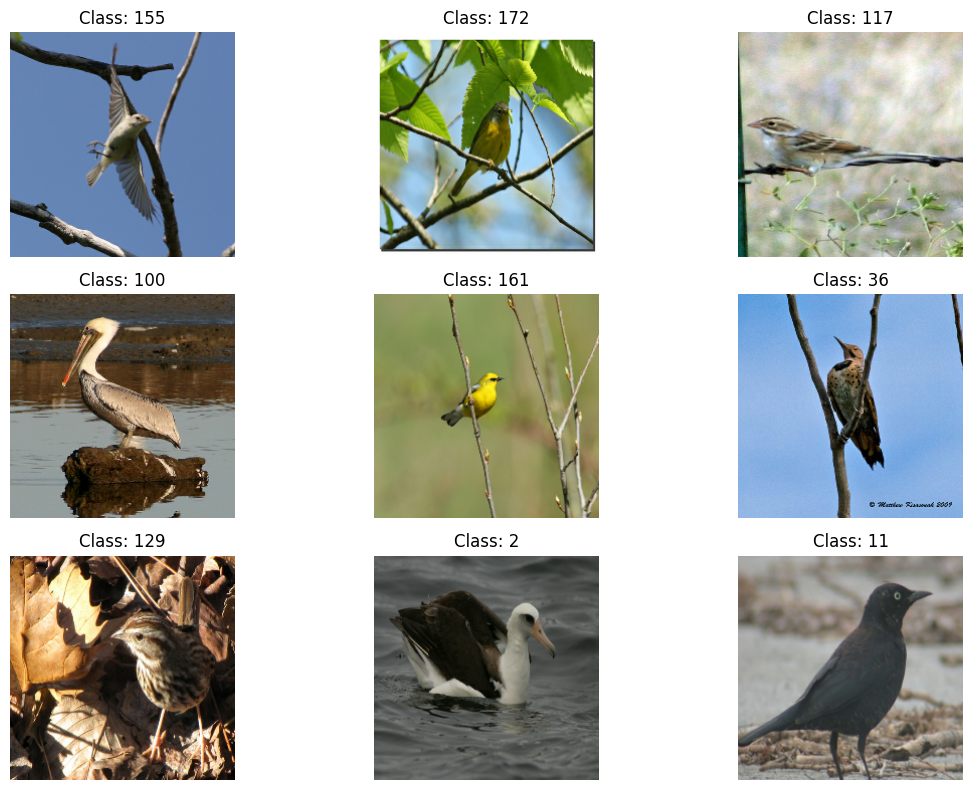

In [108]:
images, labels_batch = next(iter(train_mobilenet_ds))

plt.figure(figsize=(12, 8))

for i in range(9):

    ax = plt.subplot(3, 3, i + 1)

    image = images[i].numpy()

    # Undo MobileNet preprocessing for visualization
    image = (image + 1) * 127.5
    image = np.clip(image, 0, 255).astype("uint8")

    plt.imshow(image)

    plt.title(
        f"Class: {labels_batch[i].numpy() + 1}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [109]:
base_model = MobileNet(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [110]:
model = keras.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

In [111]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,542,664 (13.51 MB)

 Trainable params: 313,800 (1.20 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [112]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [113]:
callbacks_mobilenet = [

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
]

In [119]:
start_time = time.time()

history_mobilenet = model.fit(
    train_mobilenet_ds,
    validation_data=val_mobilenet_ds,
    epochs=30,
    callbacks=callbacks_mobilenet
)

mobilenet_training_time = time.time() - start_time

print(
    f"Training time: "
    f"{mobilenet_training_time/60:.2f} minutes"
)

Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.6702 - loss: 1.2024 - val_accuracy: 0.5522 - val_loss: 1.6467 - learning_rate: 1.0000e-05
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.6996 - loss: 1.1200 - val_accuracy: 0.5544 - val_loss: 1.6331 - learning_rate: 1.0000e-05
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.6918 - loss: 1.1230 - val_accuracy: 0.5533 - val_loss: 1.6228 - learning_rate: 1.0000e-05
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.7053 - loss: 1.0868 - val_accuracy: 0.5589 - val_loss: 1.6144 - learning_rate: 1.0000e-05
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.6975 - loss: 1.0894 - val_accuracy: 0.5578 - val_loss: 1.6059 - learning_rate: 1.0000e-05
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.7157 - loss: 1.0362 - val_accuracy: 0.5522 - val_loss: 1.5950 - learning_rate: 1.0000e-05
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/ste

In [120]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

In [121]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [127]:
fine_tune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),
    checkpoint_cb # Add the checkpoint callback here
]

start_time = time.time()

history_finetune = model.fit(
    train_mobilenet_ds,
    validation_data=val_mobilenet_ds,
    epochs=15,
    callbacks=fine_tune_callbacks
)

finetune_time = time.time() - start_time

print(f"Fine-tuning time: {finetune_time/60:.2f} minutes")

Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 22s 84ms/step - accuracy: 0.8430 - loss: 0.5980 - val_accuracy: 0.5933 - val_loss: 1.4877 - learning_rate: 1.0000e-05
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - accuracy: 0.8581 - loss: 0.5641 - val_accuracy: 0.5956 - val_loss: 1.4826 - learning_rate: 1.0000e-05
Epoch 3/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.8604 - loss: 0.5551 - val_accuracy: 0.5911 - val_loss: 1.4819 - learning_rate: 1.0000e-05
Epoch 4/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.8559 - loss: 0.5548 - val_accuracy: 0.5922 - val_loss: 1.4820 - learning_rate: 1.0000e-05
Epoch 5/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.8657 - loss: 0.5375 - val_accuracy: 0.5889 - val_loss: 1.4769 - learning_rate: 1.0000e-05
Epoch 6/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.8748 - loss: 0.5132 - val_accuracy: 0.5956 - val_loss: 1.4733 - learning_rate: 1.0000e-05
Epoch 7/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/ste

In [128]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_cb = ModelCheckpoint(
    "best_mobilenet.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [129]:
best_model = tf.keras.models.load_model("best_mobilenet.keras")

Final Evaluation

In [133]:
print("Number of classes:", len(class_names))
print("First 10 classes:", class_names[:10])
print("Last 10 classes:", class_names[-10:])

print("\nTrain labels:")
print(min(train_df['label']), max(train_df['label']))

print("\nValidation labels:")
print(min(val_df['label']), max(val_df['label']))

print("\nTest labels:")
print(min(test_df['label']), max(test_df['label']))

Number of classes: 200
First 10 classes: ['001.Black_footed_Albatross', '002.Laysan_Albatross', '003.Sooty_Albatross', '004.Groove_billed_Ani', '005.Crested_Auklet', '006.Least_Auklet', '007.Parakeet_Auklet', '008.Rhinoceros_Auklet', '009.Brewer_Blackbird', '010.Red_winged_Blackbird']
Last 10 classes: ['191.Red_headed_Woodpecker', '192.Downy_Woodpecker', '193.Bewick_Wren', '194.Cactus_Wren', '195.Carolina_Wren', '196.House_Wren', '197.Marsh_Wren', '198.Rock_Wren', '199.Winter_Wren', '200.Common_Yellowthroat']

Train labels:
0 199

Validation labels:
0 199

Test labels:
0 199


In [134]:
for images, labels in test_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

    print("First 20 labels:")
    print(labels.numpy()[:20])

    print("Pixel minimum:", tf.reduce_min(images).numpy())
    print("Pixel maximum:", tf.reduce_max(images).numpy())

Image shape: (16, 224, 224, 3)
Label shape: (16,)
First 20 labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Pixel minimum: 0.0
Pixel maximum: 255.0


In [136]:
# Evaluate MobileNetV2 on validation
print("VALIDATION:")
val_loss, val_acc = best_model.evaluate(val_mobilenet_ds, verbose=1)

# Evaluate MobileNetV2 on test
print("\nTEST:")
test_loss, test_acc = best_model.evaluate(test_mobilenet_ds, verbose=1)

print("\n==============================")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Test Accuracy:       {test_acc*100:.2f}%")
print("==============================")

VALIDATION:
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step - accuracy: 0.5956 - loss: 1.4826

TEST:
182/182 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.6053 - loss: 1.4491

Validation Accuracy: 59.56%
Test Accuracy:       60.53%


Custum CNN

In [137]:
cnn_test_loss, cnn_test_acc = custom_cnn.evaluate(
    test_ds,
    verbose=1
)

print(f"Custom CNN Accuracy: {cnn_test_acc*100:.2f}%")
print(f"Custom CNN Loss: {cnn_test_loss:.4f}")

363/363 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.1106 - loss: 4.2942
Custom CNN Accuracy: 11.06%
Custom CNN Loss: 4.2942


In [139]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Test Loss",
        "Training Time",
        "Total Parameters"
    ],

    "Custom CNN": [
        f"{cnn_test_acc*100:.2f}%",
        f"{cnn_test_loss:.4f}",
        f"{cnn_training_time/60:.2f} min",
        f"{custom_cnn.count_params():,}"
    ],

    "MobileNetV2": [
        f"{test_acc*100:.2f}%",
        f"{test_loss:.4f}",
        f"{mobilenet_training_time/60:.2f} min",
        f"{best_model.count_params():,}"
    ]
})

display(comparison)

,Metric,Custom CNN,MobileNetV2
0,Test Accuracy,11.06%,60.53%
1,Test Loss,4.2942,1.4491
2,Training Time,15.42 min,9.35 min
3,Total Parameters,"507,528","3,542,664"


In [140]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

In [141]:
def get_metrics(model, dataset):

    y_true = []
    y_pred = []

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        predictions = np.argmax(predictions, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predictions)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    accuracy = np.mean(y_true == y_pred)

    return accuracy, precision, recall, f1

In [142]:
cnn_accuracy, cnn_precision, cnn_recall, cnn_f1 = \
    get_metrics(custom_cnn, test_ds)

mobilenet_accuracy, mobilenet_precision, mobilenet_recall, mobilenet_f1 = \
    get_metrics(mobilenet_model, test_ds)

NameError: name 'mobilenet_model' is not defined

In [ ]:
comparison_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Custom CNN": [
        cnn_accuracy * 100,
        cnn_precision * 100,
        cnn_recall * 100,
        cnn_f1 * 100
    ],

    "MobileNetV2": [
        mobilenet_accuracy * 100,
        mobilenet_precision * 100,
        mobilenet_recall * 100,
        mobilenet_f1 * 100
    ]
})

comparison_metrics.round(2)

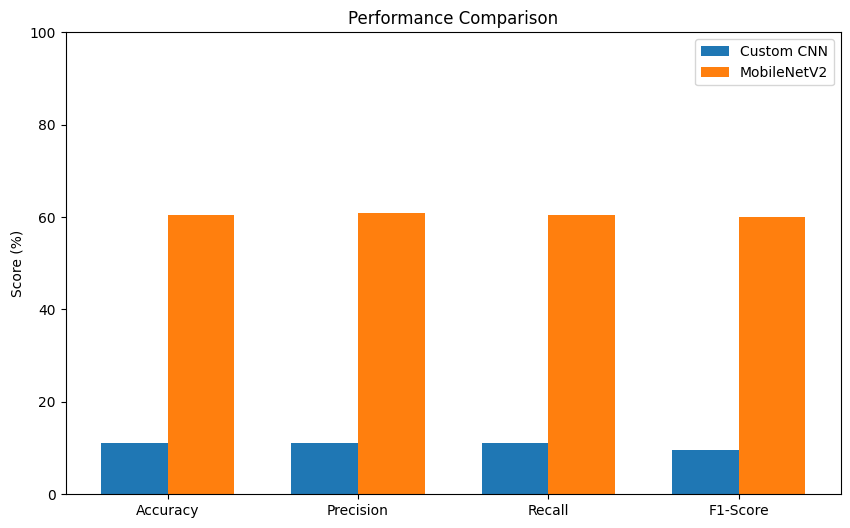

In [144]:
import matplotlib.pyplot as plt

# Calculate MobileNetV2 metrics here to ensure they are defined
mobilenet_accuracy, mobilenet_precision, mobilenet_recall, mobilenet_f1 = \
    get_metrics(best_model, test_mobilenet_ds)

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

cnn_values = [
    cnn_accuracy * 100,
    cnn_precision * 100,
    cnn_recall * 100,
    cnn_f1 * 100
]

mobilenet_values = [
    mobilenet_accuracy * 100,
    mobilenet_precision * 100,
    mobilenet_recall * 100,
    mobilenet_f1 * 100
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, cnn_values, width, label="Custom CNN")
plt.bar(x + width/2, mobilenet_values, width, label="MobileNetV2")

plt.xticks(x, metrics)
plt.ylabel("Score (%)")
plt.title("Performance Comparison")
plt.legend()
plt.ylim(0, 100)

plt.show()

In [ ]:
print(history_cnn.history.keys())
print(history_mobilenet.history.keys())

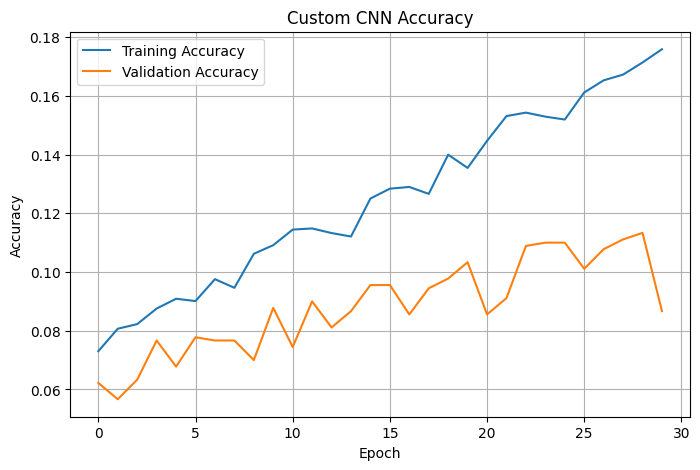

In [145]:
plt.figure(figsize=(8,5))

plt.plot(
    history_cnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Accuracy")
plt.legend()
plt.grid()

plt.show()

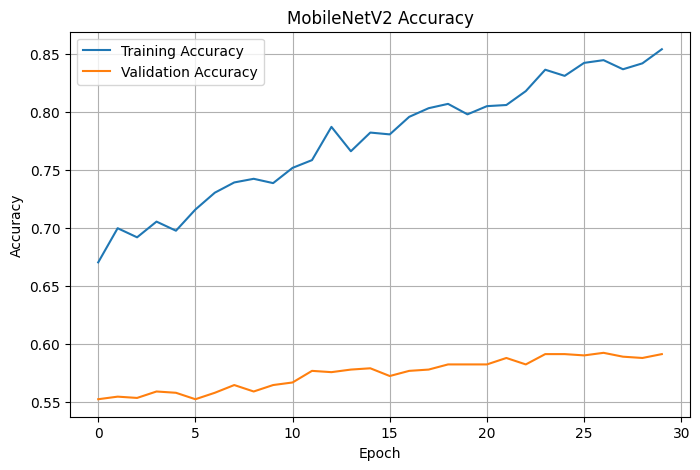

In [146]:
plt.figure(figsize=(8,5))

plt.plot(
    history_mobilenet.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_mobilenet.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.legend()
plt.grid()

plt.show()

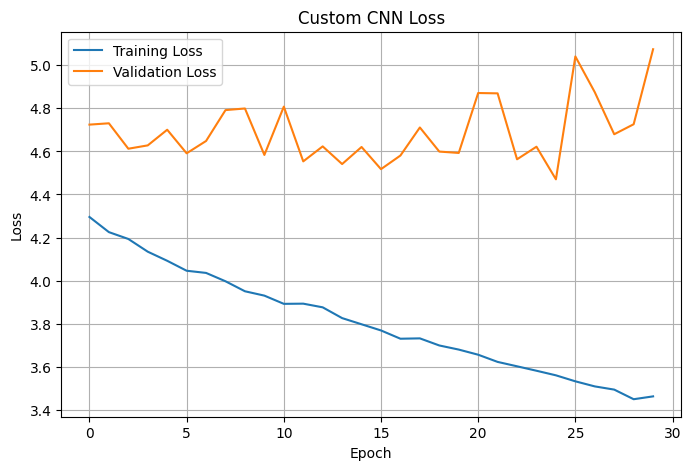

In [147]:
plt.figure(figsize=(8,5))

plt.plot(
    history_cnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_cnn.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Loss")
plt.legend()
plt.grid()

plt.show()

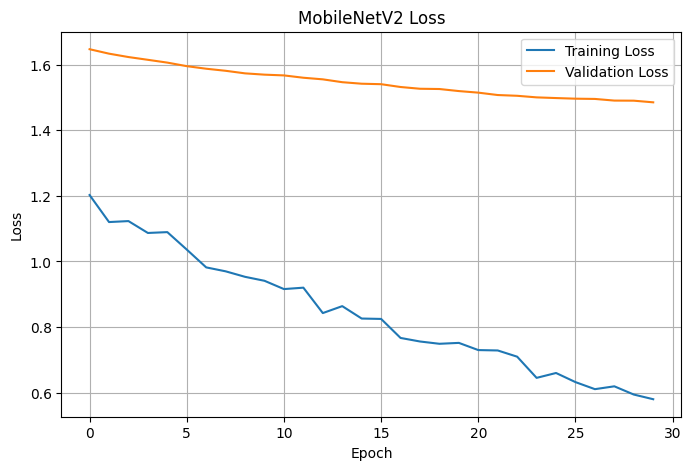

In [148]:
plt.figure(figsize=(8,5))

plt.plot(
    history_mobilenet.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_mobilenet.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Loss")
plt.legend()
plt.grid()

plt.show()

In [149]:
from sklearn.metrics import confusion_matrix

def get_predictions(model, dataset):

    y_true = []
    y_pred = []

    for images, labels in dataset:

        predictions = model.predict(images, verbose=0)

        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(predictions, axis=1))

    return np.array(y_true), np.array(y_pred)

In [151]:
y_true_cnn, y_pred_cnn = get_predictions(
    custom_cnn,
    test_ds
)

y_true_mobilenet, y_pred_mobilenet = get_predictions(
    best_model,
    test_mobilenet_ds
)

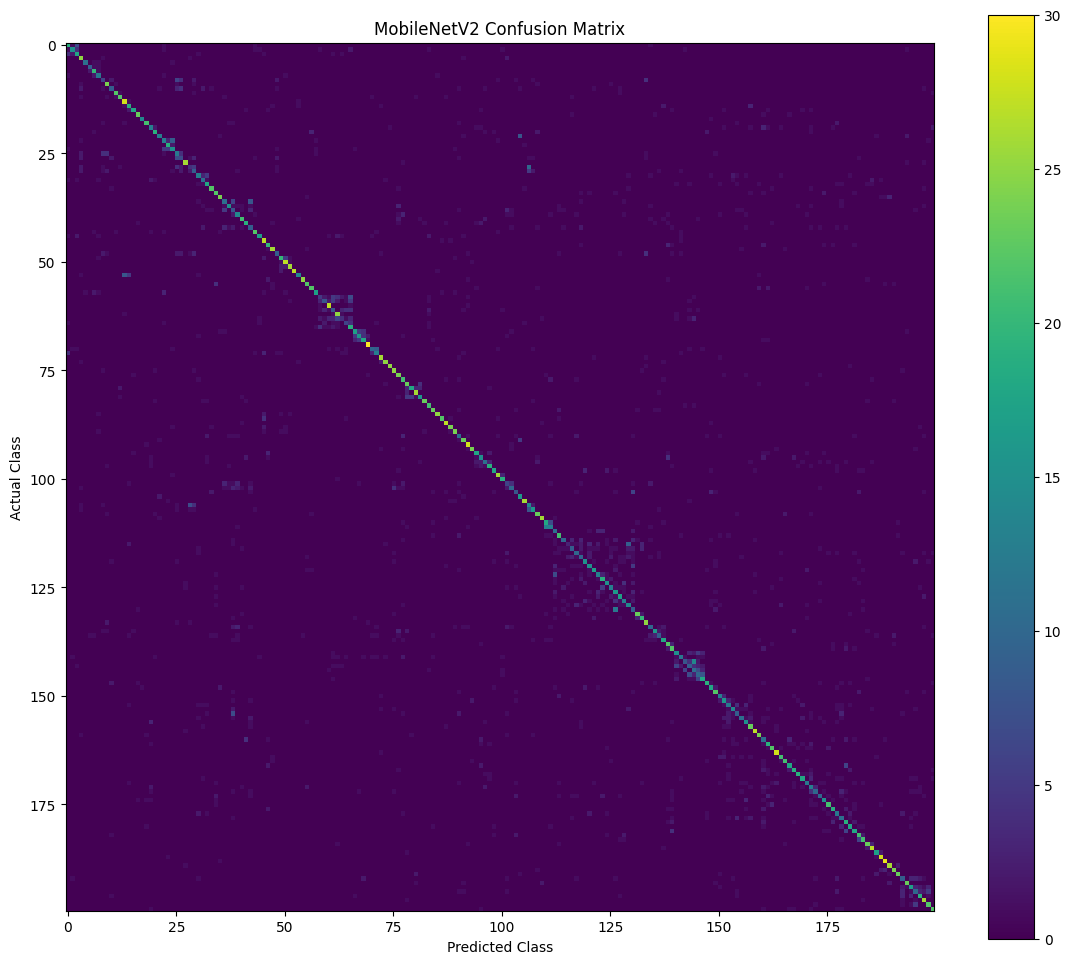

In [152]:
cm_mobilenet = confusion_matrix(
    y_true_mobilenet,
    y_pred_mobilenet
)

plt.figure(figsize=(14,12))

plt.imshow(cm_mobilenet)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.colorbar()

plt.show()